In [3]:
!/Users/lmv/anaconda3/envs/mlfinance/bin/pip install PyPortfolioOpt

  Installing build dependencies done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 2.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 4.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.1/935.1 kB 4.3 MB/s eta 0:00:00
  Created wheel for ecos: filename=ecos-2.0.14-cp310-cp310-macosx_11_0_arm64.whl size=72451 sha256=4af12555de2980ec7c30d21caa9767ea3c01b313ab35e349b6ed3c08af4b30e9
  Stored in directory: /Users/lmv/Library/Caches/pip/wheels/e1/cf/5e/e0839639dc3777967d18c04d65e5233e81049a89259062c081
Successfully built ecos
  Attempting uninstall: plotly
    Found existing installation: plotly 6.0.1
    Uninstalling plotly-6.0.1:
      Successfully uninstalled plotly-6.0.1


In [5]:
!/Users/lmv/anaconda3/envs/mlfinance/bin/pip install tqdm

In [14]:
import yfinance as yf
import pandas as pd

from pypfopt.efficient_frontier import EfficientFrontier 
from pypfopt import risk_models 
from pypfopt import expected_returns, get_latest_prices, DiscreteAllocation
from pypfopt.cla import CLA
import pypfopt.plotting as pplt

from collections import OrderedDict
from matplotlib.ticker import FuncFormatter

from sqlalchemy import create_engine
from tqdm import tqdm

import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

import IPython
import IPython.display
import matplotlib as mpl

mpl.rcParams['figure.figsize'] = (12, 6)
mpl.rcParams['axes.grid'] = False

# Загрузим данные акций
Стоит уточнить, что реальный портфель лучше формировать из разных инструментов. Акции выбраны для примера

In [8]:
df_stocks = pd.read_csv('stocks_day.csv.gz')
df_stocks.head()

,time,krot,vkco,svav,vsmo,nomp,grnt,nsvz,gltr,cntlp,...,obne,kzizp,vtbr,rbcm,t,ozon,chmk,alrs,mgnt,mgkl
0,2023-12-11 00:00:00+00:00,2322.0,575.0,712.0,30860.0,499.99,0.2484,479.0,594.0,10.40,...,1850.00,565.00,112.98,7.90,3111.6,2684.5,9500.0,72.26,6193.0,NaN
1,2023-12-12 00:00:00+00:00,2310.0,546.8,690.0,30120.0,473.99,0.2400,465.0,587.9,10.56,...,1900.00,554.98,114.48,7.85,3097.6,2596.0,9500.0,72.62,6137.5,NaN
2,2023-12-13 00:00:00+00:00,2298.0,563.0,696.0,29200.0,499.99,0.2200,470.0,583.5,11.16,...,1849.71,547.00,113.93,7.76,3085.6,2634.0,9590.0,73.14,6128.0,NaN
3,2023-12-14 00:00:00+00:00,2232.0,564.0,697.5,28980.0,497.00,0.2088,464.0,581.0,11.80,...,1620.00,538.00,115.75,7.48,3087.0,2648.5,9610.0,71.81,6165.5,NaN
4,2023-12-15 00:00:00+00:00,2309.0,573.4,713.0,28880.0,464.00,0.1982,460.0,593.8,11.14,...,1530.00,530.00,118.10,7.39,3026.0,2644.5,9700.0,71.89,6398.0,NaN


**В данных не должно быть пропусков**

In [9]:
print(df_stocks.isnull().sum().sort_values(ascending=False)[:20])

data     205
sftl     175
prmd     148
vseh     143
hhru      82
leas      75
klvz      51
grnt      46
deli      40
gltr      32
udmn      20
t         19
mgkl      13
obne       5
gmkn       4
trnfp      4
svcb       4
vtbr       4
unkl       0
orup       0
dtype: int64


# Выводы

Здесь явно можно часть акций просто убрать, так как информация о них отсутствует больше чем в 50% дней. Но правда все зависит от вашего подхода и какие признаки будут использоваться для построения моделей. Я для простоты уберу все акции, по которым есть хотя бы один пропуск. Вы же можете заполнить пропуски известными вам методами)

In [10]:
df_stocks = df_stocks.dropna(axis=1)
df_stocks_for_analysis = df_stocks.drop(columns='time')

In [11]:
df_stocks_for_analysis.corr()

,krot,vkco,svav,vsmo,nomp,nsvz,cntlp,abio,elfv,msng,...,sfin,nompp,rual,vrsb,kzizp,rbcm,ozon,chmk,alrs,mgnt
krot,1.000000,0.923106,0.712573,0.944348,0.728175,0.937061,0.930546,0.785470,0.796030,0.861388,...,-0.064955,0.762363,0.387922,0.896953,0.700760,0.055601,0.300759,0.877088,0.871331,0.898401
vkco,0.923106,1.000000,0.661320,0.952930,0.803774,0.959500,0.972854,0.752722,0.829163,0.911418,...,-0.068931,0.809725,0.292726,0.896865,0.766932,-0.118916,0.207328,0.938009,0.914306,0.909356
svav,0.712573,0.661320,1.000000,0.702503,0.309670,0.669143,0.640200,0.595026,0.449484,0.712018,...,0.109623,0.328574,0.678682,0.645051,0.299259,0.351151,0.629553,0.501589,0.765319,0.714473
vsmo,0.944348,0.952930,0.702503,1.000000,0.734886,0.960924,0.951691,0.826162,0.811625,0.908171,...,0.009317,0.762414,0.385954,0.932500,0.711081,0.028797,0.290325,0.891173,0.901698,0.933775
nomp,0.728175,0.803774,0.309670,0.734886,1.000000,0.782624,0.849254,0.666238,0.841756,0.678547,...,-0.456670,0.966177,0.018205,0.653763,0.879340,-0.490242,-0.266702,0.911625,0.666894,0.669987
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
rbcm,0.055601,-0.118916,0.351151,0.028797,-0.490242,-0.017660,-0.169143,-0.037438,-0.417498,0.049212,...,0.541543,-0.400628,0.674909,-0.045794,-0.443680,1.000000,0.871006,-0.302883,0.170457,0.177885
ozon,0.300759,0.207328,0.629553,0.290325,-0.266702,0.251462,0.122593,0.132155,-0.199908,0.360521,...,0.552950,-0.200147,0.800234,0.196450,-0.244810,0.871006,1.000000,-0.042327,0.484409,0.445630
chmk,0.877088,0.938009,0.501589,0.891173,0.911625,0.918677,0.956540,0.742424,0.908922,0.809180,...,-0.294831,0.924124,0.104122,0.830891,0.816484,-0.302883,-0.042327,1.000000,0.805572,0.800118
alrs,0.871331,0.914306,0.765319,0.901698,0.666894,0.913796,0.878260,0.735227,0.635719,0.914349,...,0.086082,0.689179,0.566217,0.779008,0.606090,0.170457,0.484409,0.805572,1.000000,0.947140


<Axes: >

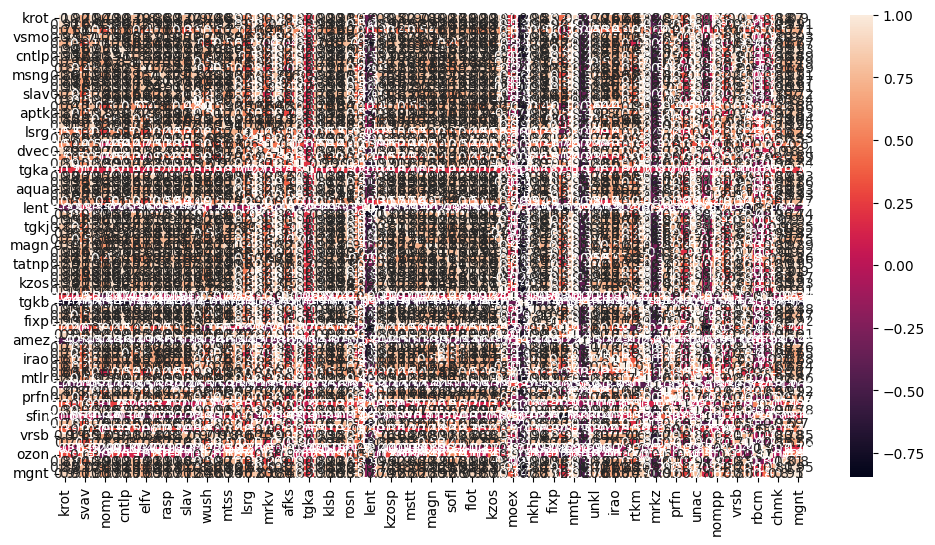

In [15]:
sns.heatmap(df_stocks_for_analysis.corr(), annot=True)

По итогу получили веса и годовую доходность активов

# Алгоритм максимизации коэффициент Шарпа

In [20]:
#Годовая доходность
mu = expected_returns.mean_historical_return(df_stocks_for_analysis)
#Дисперсия портфеля
Sigma = risk_models.sample_cov(df_stocks_for_analysis)
#Максимальный коэффициент Шарпа

#Необходимо обратить внимание, что если изменить weight_bounds=(0,1) на weight_bounds=(-1,1), 
#то в портфеле будут учитываться и короткие позиции по акциям.

ef = EfficientFrontier(mu, Sigma, weight_bounds=(0,1)) #weight bounds in negative allows shorting of stocks
sharpe_pfolio = ef.max_sharpe() #May use add objective to ensure minimum zero weighting to individual stocks
sharpe_pwt = ef.clean_weights()
print(sharpe_pwt)

# OrderedDict([('AFLT.ME', 0.0), ('DSKY.ME', 0.22606), ('GMKN.ME', 0.48796), ('IRAO.ME', 0.0), ('LKOH.ME', 0.0), ('MTSS.ME', 0.02953), ('NKNC.ME', 0.25645), ('SBER.ME', 0.0)])

ef.portfolio_performance(verbose=True)

OrderedDict([('krot', 0.0), ('vkco', 0.0), ('svav', 0.0), ('vsmo', 0.0), ('nomp', 0.0), ('nsvz', 0.0), ('cntlp', 0.0), ('abio', 0.0), ('elfv', 0.0), ('msng', 0.0), ('rasp', 0.0), ('ogkb', 0.0), ('slav', 0.0), ('nknc', 0.0), ('wush', 0.0), ('aptk', 0.0), ('mtss', 0.0), ('etln', 0.0), ('lsrg', 0.0), ('rolo', 0.0), ('mrkv', 0.0), ('dvec', 0.0), ('afks', 0.0), ('sgzh', 0.0), ('tgka', 0.00012), ('enpg', 0.0), ('klsb', 0.0), ('aqua', 0.0), ('rosn', 0.0), ('lkoh', 0.0), ('lent', 0.44052), ('nvtk', 0.0), ('kzosp', 0.0), ('tgkj', 0.0), ('mstt', 0.0), ('mrks', 0.0), ('magn', 0.0), ('geco', 0.0), ('sofl', 0.0), ('tatnp', 0.0), ('flot', 0.0), ('mgtsp', 0.0), ('kzos', 0.0), ('lnzl', 0.0), ('moex', 0.0), ('tgkb', 0.00584), ('nkhp', 0.0), ('eutr', 0.0), ('fixp', 0.0), ('qiwi', 0.0), ('nmtp', 0.0), ('amez', 0.0), ('unkl', 0.0), ('orup', 0.0), ('irao', 0.0), ('ttlk', 0.00048), ('rtkm', 0.0), ('mtlr', 0.0), ('mrkz', 0.0), ('chmf', 0.0), ('prfn', 0.0), ('lsngp', 0.0), ('unac', 0.0), ('sfin', 0.46443), ('

(np.float64(0.9943683569319015),
 np.float64(0.4247806531628631),
 np.float64(2.340898413164442))

# Mean-Variance Optimization 

In [17]:
ef1 = EfficientFrontier(mu, Sigma, weight_bounds=(0,1)) 
minvol = ef1.min_volatility()
minvol_pwt = ef1.clean_weights()
print(minvol_pwt)


ef1.portfolio_performance(verbose=True, risk_free_rate = 0.27)


OrderedDict([('krot', 0.0), ('vkco', 0.0), ('svav', 0.0), ('vsmo', 0.0), ('nomp', 0.00621), ('nsvz', 0.0), ('cntlp', 0.0), ('abio', 0.0), ('elfv', 0.08604), ('msng', 0.0), ('rasp', 0.0), ('ogkb', 0.0006), ('slav', 0.00493), ('nknc', 0.0381), ('wush', 0.0), ('aptk', 0.00463), ('mtss', 0.0), ('etln', 0.0), ('lsrg', 0.0), ('rolo', 0.0), ('mrkv', 0.01752), ('dvec', 0.0), ('afks', 0.0), ('sgzh', 0.0), ('tgka', 0.00026), ('enpg', 0.0), ('klsb', 0.0), ('aqua', 0.0), ('rosn', 0.16684), ('lkoh', 0.36898), ('lent', 0.0), ('nvtk', 0.01534), ('kzosp', 0.0), ('tgkj', 0.0), ('mstt', 0.0), ('mrks', 0.0), ('magn', 0.01826), ('geco', 0.0), ('sofl', 0.0), ('tatnp', 0.0), ('flot', 0.0), ('mgtsp', 0.0), ('kzos', 0.03267), ('lnzl', 0.07365), ('moex', 0.03073), ('tgkb', 0.00235), ('nkhp', 0.0), ('eutr', 0.0), ('fixp', 0.0), ('qiwi', 0.0), ('nmtp', 0.0), ('amez', 0.00058), ('unkl', 0.0), ('orup', 0.01428), ('irao', 0.0), ('ttlk', 0.0), ('rtkm', 0.0), ('mtlr', 0.0), ('mrkz', 0.0), ('chmf', 0.0), ('prfn', 0.0)

(np.float64(-0.10455583369659899),
 np.float64(0.13143981705937166),
 np.float64(-2.8496375153003393))

# Создание графика эффективной границы

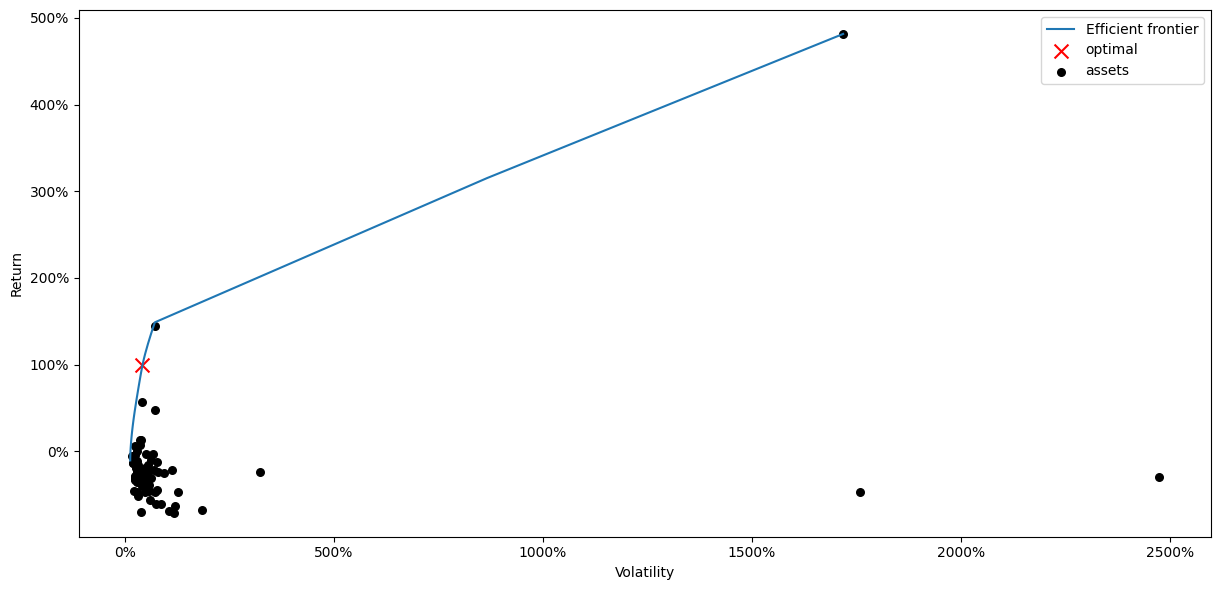

In [18]:
cl_obj = CLA(mu, Sigma)
ax = pplt.plot_efficient_frontier(cl_obj, showfig = False)
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: '{:.0%}'.format(x)))
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:.0%}'.format(y)))

In [43]:
dbs = pd.DataFrame.from_dict(dict(minvol_pwt), orient = 'index')
dbs = dbs.reset_index()
dbs.columns = ['key', 'value']
dbs1 = dbs[dbs['value']!=0].sort_values('value', ascending=False).reset_index(drop=True)
dbskeys1 = dbs1['key']
dbs2 = dbs[dbs['value']==0].reset_index(drop=True)
dbskeys2 = dbs2['key']
dbs1

,key,value
0,lkoh,0.36898
1,rosn,0.16684
2,elfv,0.08604
3,lsngp,0.08240
4,lnzl,0.07365
5,nknc,0.03810
6,rual,0.03449
7,kzos,0.03267
8,moex,0.03073
9,magn,0.01826


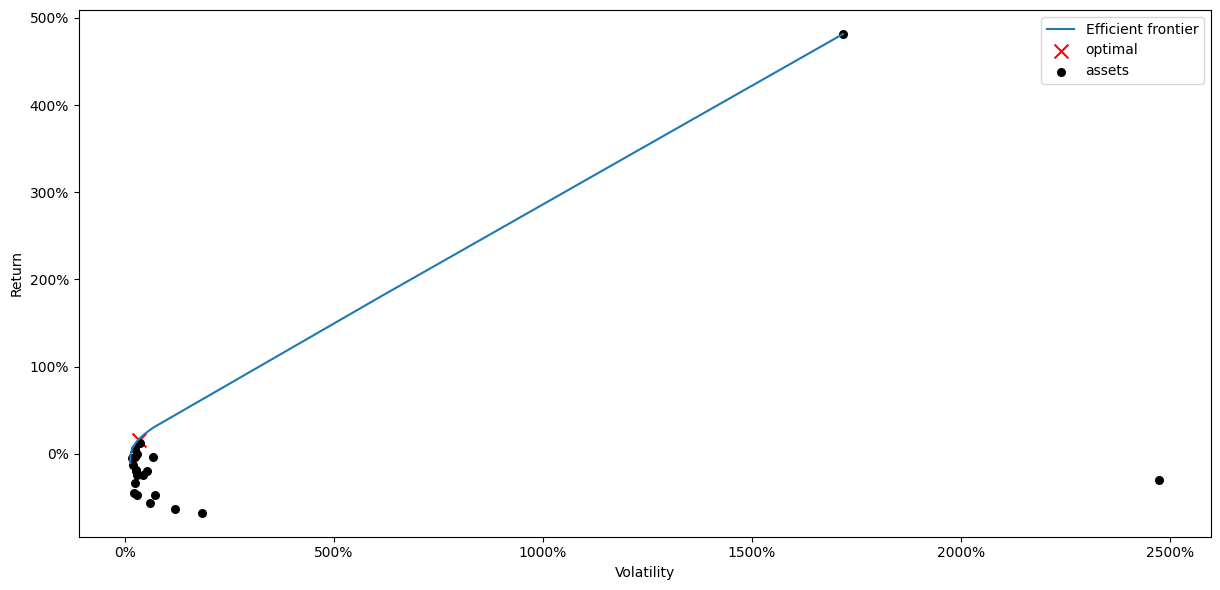

In [44]:
#Годовая доходность
mu1 = expected_returns.mean_historical_return(df_stocks_for_analysis[dbskeys1])
#Дисперсия портфеля
Sigma1 = risk_models.sample_cov(df_stocks_for_analysis[dbskeys1])

cl_obj = CLA(mu1, Sigma1)
ax = pplt.plot_efficient_frontier(cl_obj, showfig = False)
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: '{:.0%}'.format(x)))
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:.0%}'.format(y)))

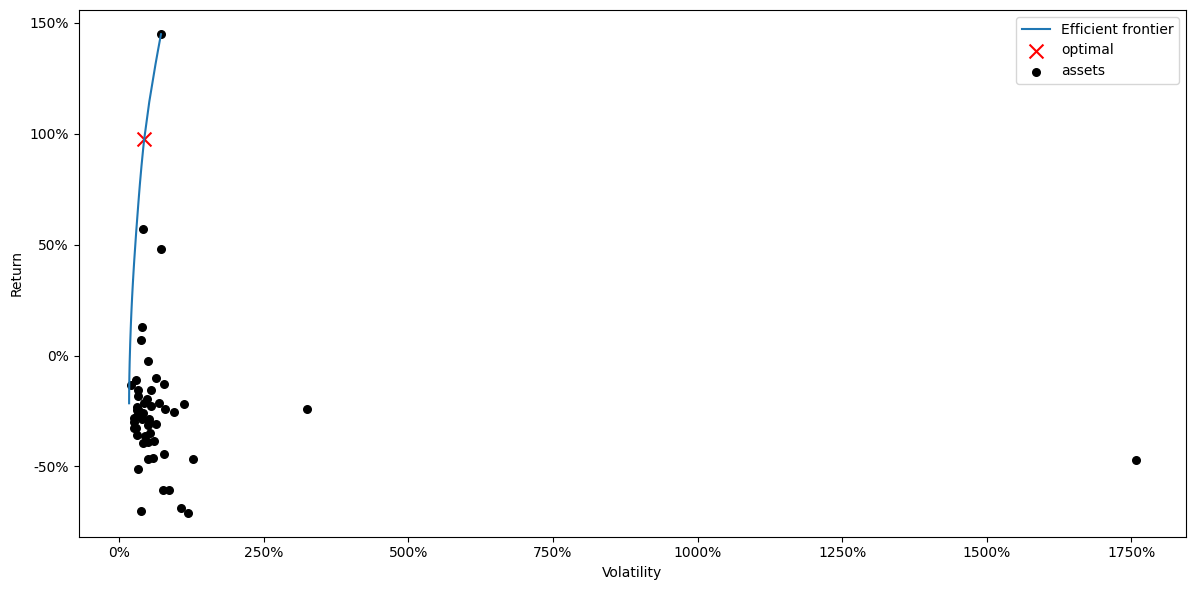

In [46]:
#Годовая доходность
mu2 = expected_returns.mean_historical_return(df_stocks_for_analysis[dbskeys2])
#Дисперсия портфеля
Sigma2 = risk_models.sample_cov(df_stocks_for_analysis[dbskeys2])

cl_obj = CLA(mu2, Sigma2)
ax = pplt.plot_efficient_frontier(cl_obj, showfig = False)
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: '{:.0%}'.format(x)))
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:.0%}'.format(y)))

# А можно просто сказать мне сколько куда мне надо положить денег?

In [47]:
latest_prices = get_latest_prices(df_stocks_for_analysis)
allocation_minv, rem_minv = DiscreteAllocation(minvol_pwt,
                                               latest_prices, 
                                               total_portfolio_value=1_000_000).lp_portfolio() 
print(allocation_minv)
print("Осталось денежных средств после построения портфеля с минимальной волатильностью - {:.2f} рублей".format(rem_minv))
print()

{'nomp': 28, 'elfv': 175664, 'ogkb': 2063, 'slav': 125, 'nknc': 456, 'aptk': 450, 'rolo': 5, 'mrkv': 28868, 'dvec': 1, 'sgzh': 1, 'tgka': 421, 'rosn': 338, 'lkoh': 54, 'nvtk': 18, 'mrks': 4, 'magn': 538, 'kzos': 431, 'lnzl': 6, 'moex': 160, 'tgkb': 3874, 'amez': 8, 'orup': 10121, 'ttlk': 2, 'mrkz': 9, 'lsngp': 428, 'unac': 2, 'rual': 960, 'kzizp': 4}
Осталось денежных средств после построения портфеля с минимальной волатильностью - 1619.98 рублей



In [48]:
latest_prices1 = get_latest_prices(df_stocks_for_analysis)
allocation_shp, rem_shp = DiscreteAllocation(sharpe_pwt, latest_prices1, total_portfolio_value=1_000_000).lp_portfolio() 
print(allocation_shp)
print("Осталось денежных средств после построения портфеля с максимальным коэффициентом Шарпа {:.2f} рублей".format(rem_shp))

{'cntlp': 1, 'elfv': 16, 'msng': 4, 'ogkb': 14, 'aptk': 1, 'rolo': 15, 'mrkv': 13, 'dvec': 4, 'afks': 1, 'sgzh': 6, 'tgka': 202, 'lent': 413, 'mrks': 17, 'tgkb': 9633, 'nmtp': 1, 'orup': 6, 'irao': 2, 'ttlk': 762, 'mrkz': 16, 'prfn': 2, 'unac': 13, 'sfin': 333, 'rbcm': 7607}
Осталось денежных средств после построения портфеля с максимальным коэффициентом Шарпа 34.26 рублей


# Кластеризация данных

In [49]:
!/Users/lmv/anaconda3/envs/mlfinance/bin/pip install tslearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 5.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 6.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.2/26.2 MB 5.3 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.7.0
    Uninstalling scikit-learn-1.7.0:
      Successfully uninstalled scikit-learn-1.7.0


In [50]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans 
from sklearn.preprocessing import MinMaxScaler

# Посмотрим на акции

<Axes: >

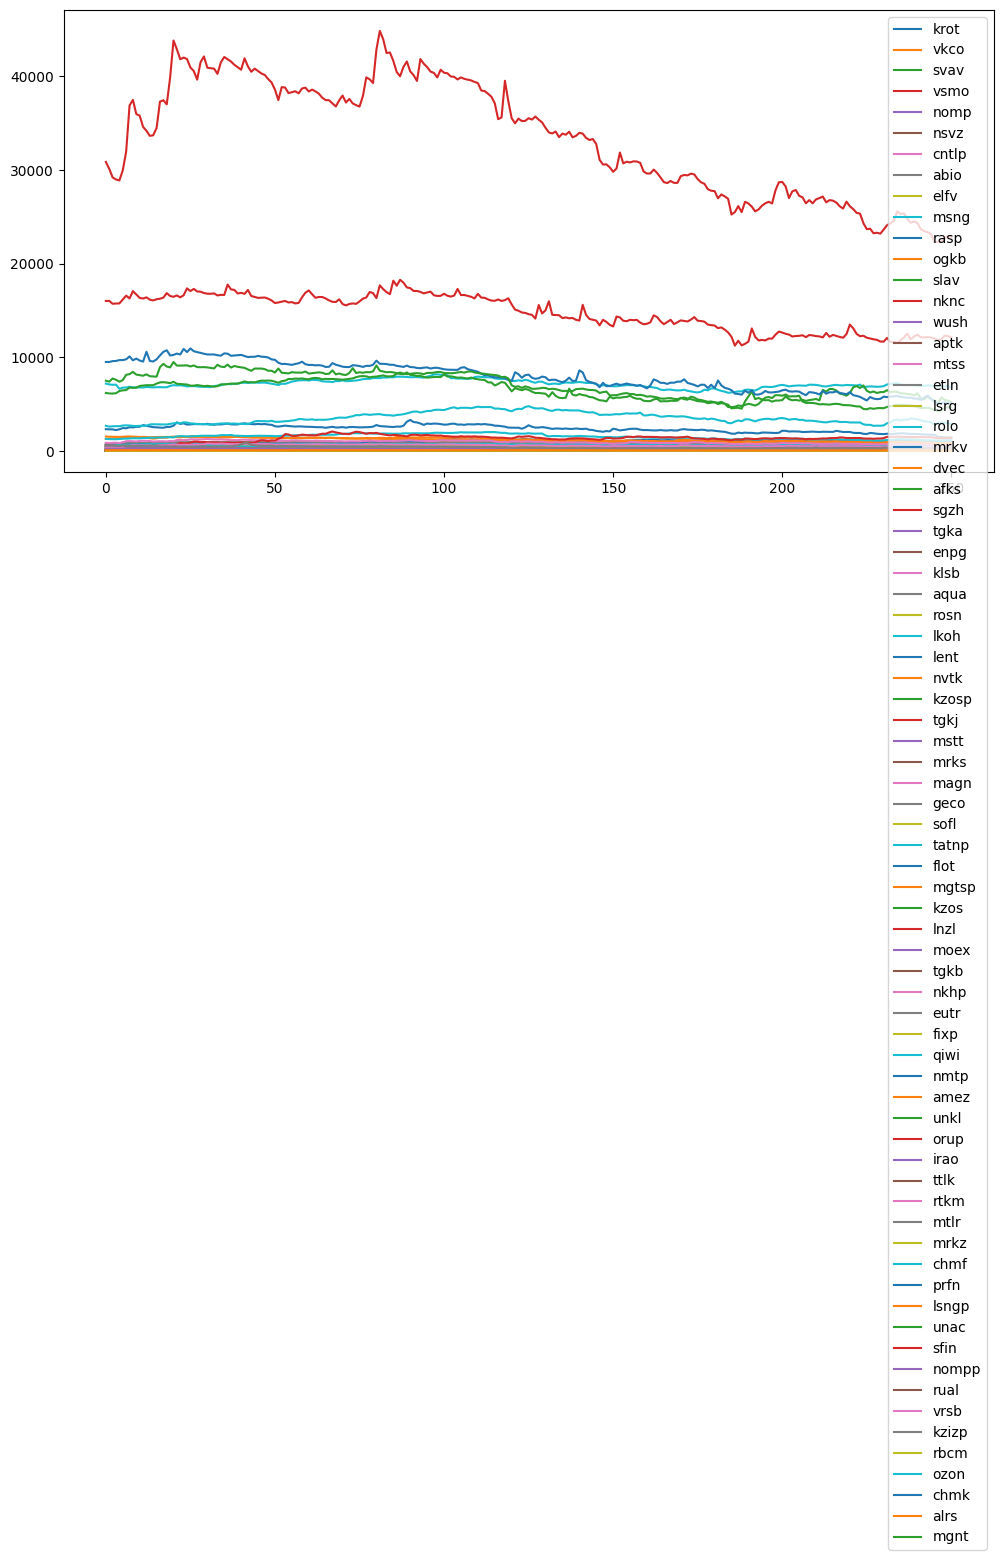

In [51]:
df_stocks.plot()

В таком виде их будет сложно разделить на группы, так как стоимость этих акций сильно отличается и они разной размерности

# Нормализация данных

<Axes: >

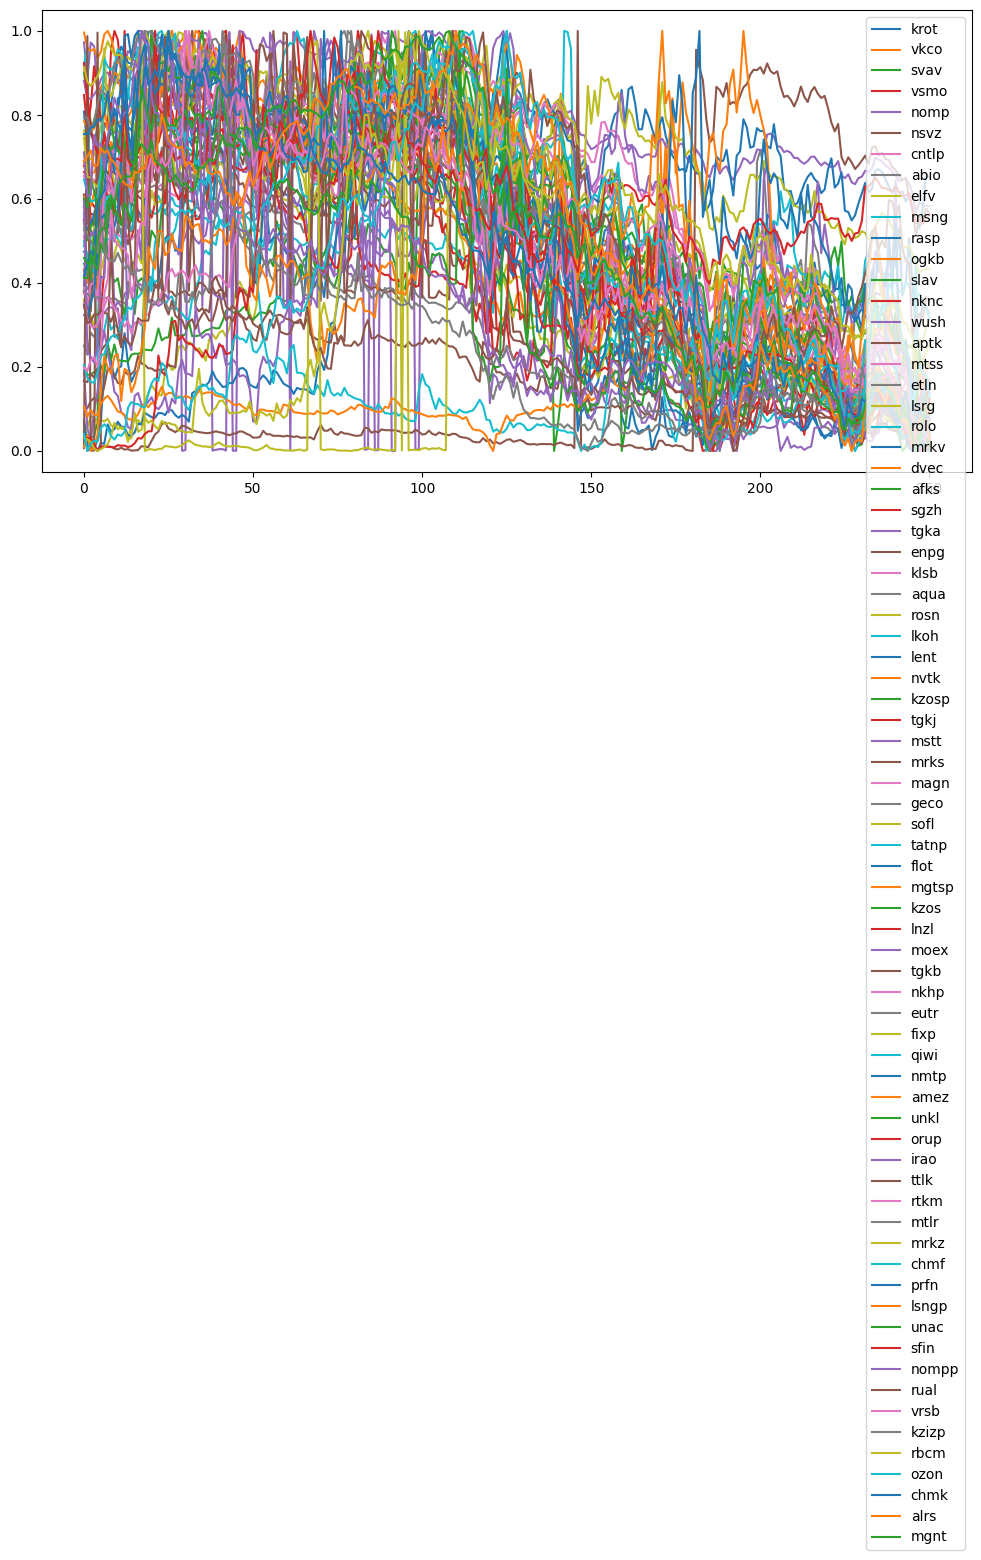

In [52]:
scaler = MinMaxScaler()
df_cluster = scaler.fit_transform(df_stocks_for_analysis)
df_cluster = pd.DataFrame(df_cluster, columns = df_stocks_for_analysis.columns)
df_cluster.plot()

# Kmeans
Будем использовать подход kmeans, так как он самый простой в реализации и способен быстро обробатывать большие объемы данных

In [53]:
# Нужно задать число кластеров, тут придется работать по наитию. 
# Можно попробовать поварьировать этот параметр для достижения лучшего результата
clusters = 8
assetsCluster = KMeans(algorithm='elkan',  max_iter=800, n_clusters=clusters)
print('Clustering of assets completed!') 
assetsCluster.fit(df_cluster[-180:].T)
centroids = assetsCluster.cluster_centers_
labels = assetsCluster.labels_

Clustering of assets completed!


#  Посмотрим из чего состоят получившиеся акции

In [54]:
#fixing asset labels to cluster points
print('Stocks in each of the clusters:\n',)
assets = np.array(df_cluster.columns)
for i in range(clusters):
    print('Cluster', i+1)
    clt  = np.where(labels == i)
    assetsCluster = assets[clt]
    print(assetsCluster)

Stocks in each of the clusters:

Cluster 1
['tgkb']
Cluster 2
['vkco' 'vsmo' 'nsvz' 'msng' 'rasp' 'ogkb' 'wush' 'mtss' 'etln' 'afks'
 'enpg' 'aqua' 'rosn' 'kzosp' 'geco' 'flot' 'kzos' 'lnzl' 'fixp' 'mtlr'
 'chmf' 'alrs' 'mgnt']
Cluster 3
['nomp' 'mrks' 'eutr' 'qiwi' 'orup' 'ttlk' 'nompp' 'kzizp']
Cluster 4
['krot' 'svav' 'cntlp' 'abio' 'elfv' 'slav' 'dvec' 'klsb' 'lkoh' 'mstt'
 'sofl' 'mgtsp' 'nkhp' 'prfn' 'vrsb']
Cluster 5
['mrkv' 'tgka' 'lent' 'magn' 'tatnp' 'moex' 'rtkm' 'lsngp' 'sfin' 'rual'
 'rbcm' 'ozon']
Cluster 6
['mrkz']
Cluster 7
['amez']
Cluster 8
['nknc' 'aptk' 'lsrg' 'rolo' 'sgzh' 'nvtk' 'tgkj' 'nmtp' 'unkl' 'irao'
 'unac' 'chmk']


<Axes: >

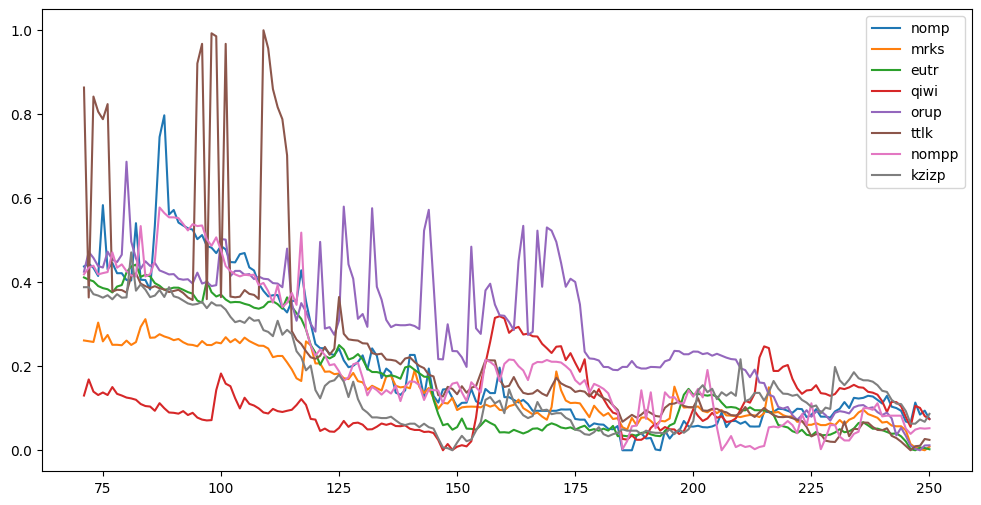

In [55]:
df_cluster[-180:].plot(y=['nomp', 'mrks', 'eutr', 'qiwi', 'orup', 'ttlk', 'nompp', 'kzizp'])

<Axes: >

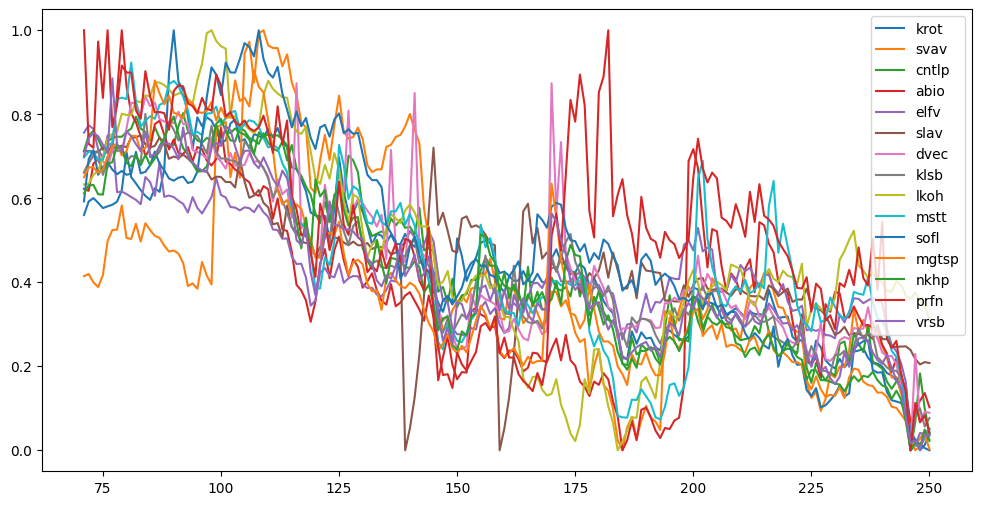

In [56]:
df_cluster[-180:].plot(y=['krot', 'svav', 'cntlp', 'abio', 'elfv', 'slav', 'dvec', 'klsb', 'lkoh', 'mstt',
 'sofl', 'mgtsp', 'nkhp', 'prfn', 'vrsb'])

In [57]:
from tslearn.clustering import TimeSeriesKMeans
n_clusters = 8
model = TimeSeriesKMeans(n_clusters=n_clusters, metric="dtw",
                         max_iter=10, random_state=42)
model.fit(df_cluster[-180:].T)

TimeSeriesKMeans(max_iter=10, metric='dtw', n_clusters=8, random_state=42)

In [58]:


centroids = model.cluster_centers_
labels = model.labels_

assets = np.array(df_cluster.columns)
for i in range(n_clusters):
    print('Cluster', i+1)
    clt  = np.where(labels == i)
    assetsCluster = assets[clt]
    print(assetsCluster)

Cluster 1
['amez']
Cluster 2
['slav' 'dvec' 'rosn' 'mstt' 'tatnp' 'prfn' 'sfin']
Cluster 3
['nomp' 'rolo' 'eutr' 'orup' 'ttlk' 'unac' 'nompp' 'kzizp']
Cluster 4
['krot' 'svav' 'lsrg' 'mrkv' 'lkoh' 'moex' 'lsngp' 'rual' 'rbcm' 'ozon']
Cluster 5
['tgka']
Cluster 6
['lent' 'tgkb' 'mrkz']
Cluster 7
['vkco' 'vsmo' 'nsvz' 'cntlp' 'abio' 'elfv' 'msng' 'rasp' 'ogkb' 'nknc'
 'wush' 'aptk' 'mtss' 'etln' 'afks' 'sgzh' 'enpg' 'klsb' 'aqua' 'nvtk'
 'kzosp' 'tgkj' 'magn' 'geco' 'sofl' 'flot' 'mgtsp' 'kzos' 'lnzl' 'nkhp'
 'fixp' 'nmtp' 'unkl' 'irao' 'rtkm' 'mtlr' 'chmf' 'vrsb' 'chmk' 'alrs'
 'mgnt']
Cluster 8
['mrks' 'qiwi']


# Итог 
можно взять из каждой группы по одной акции, тем самым мы с большей вероятностью понизим риски

In [148]:
vc = df_cluster.iloc[-1:, :].reset_index(drop=True)
vc = [float(vc.loc[0, x]) for x in vc.columns]
vc[:10]

[0.0,
 0.039024390243902585,
 0.026151930261519407,
 0.023978685612788597,
 0.07461331430980245,
 0.057640750670241214,
 0.04225352112676062,
 0.10238095238095224,
 0.05139500734214386,
 0.033582089552238736]

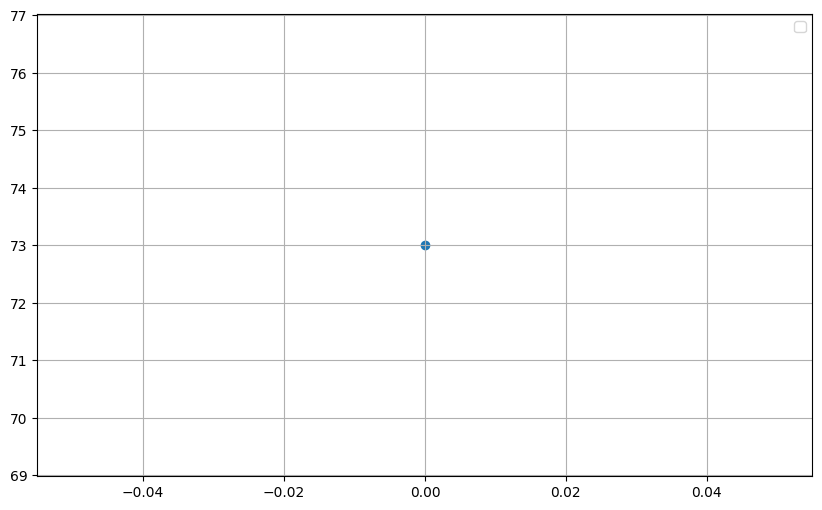

In [149]:
ver, ver2 = middle(vc, subplot = True)

In [140]:
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import silhouette_samples
random_state = 42

In [141]:
def middle(vc, subplot = False):
    X = np.zeros((len(vc), 2), dtype = int)
    X[:,0] = [int(x) for x in vc]    
    ver = []
    silhouette = []
    clusters_range = range(2, int(len(X)/2)-1)
    batch_range = range(2, int(len(X)))
    for n_clusters in (clusters_range):
        for batch in (batch_range):
            silhouette_avg = 0
            try:
                clusterer = MiniBatchKMeans(batch_size=batch, compute_labels=True, init='k-means++', init_size=None, max_iter=10, tol=0.0001, max_no_improvement=10, n_clusters=n_clusters, random_state=random_state, n_init=n_clusters, reassignment_ratio=0.05, verbose=0)
                cluster_labels = clusterer.fit_predict(X)
                silhouette_avg = silhouette_score(X, cluster_labels)
                silhouette.append(silhouette_avg)    
            except:
                pass
            ver.append([silhouette_avg, n_clusters, batch])            
    ver = pd.DataFrame(ver, columns = ['silhouette_avg', 'n_clusters', 'batch'])
    ver = ver.drop_duplicates(['silhouette_avg', 'n_clusters'], keep='first').reset_index(drop=True)
    
    # выбираю лучшие кластера    
    ind = ver[ver['silhouette_avg'] >= np.mean(ver['silhouette_avg'])].index
    ver['cls'] = 0; ver.loc[ind, 'cls'] = 1
    ver2 = ver[ver['cls'] == 1].reset_index(drop=True)
    ver2 = ver2[ver2['silhouette_avg'] >= np.max(ver2['silhouette_avg'])*0.9].reset_index(drop=True)
    ver2 = ver2[ver2['n_clusters'] == np.min(ver2['n_clusters'])].reset_index(drop=True)
    clusterer = MiniBatchKMeans(batch_size=ver2.loc[0, 'batch'], compute_labels=True, init='k-means++', init_size=None, max_iter=10, tol=0.0001, max_no_improvement=10, n_clusters=ver2.loc[0, 'n_clusters'], random_state=random_state, n_init=ver2.loc[0, 'n_clusters'], reassignment_ratio=0.05, verbose=0)
    labels_M = clusterer.fit_predict(X)    

    X[:,1] = labels_M

    # посмотреть    
    if subplot:
        Z = pd.DataFrame(X, columns = ['X','y'])
        dsx = pd.DataFrame(Z.groupby(['X','y'])[['y']].count())
        dsx = dsx.rename(columns={'y':'value'})
        dsx.reset_index(inplace=True)
        fig, ax = plt.subplots(figsize = (10, 6))
        for c in dsx['y'].unique():
            x = dsx[dsx['y'] == c]
            ax.scatter(x['X'], x['value']);
            ax.plot(x['X'], x['value']);
        ax.grid(True)
        ax.legend(loc = 'upper right')
    return ver, ver2


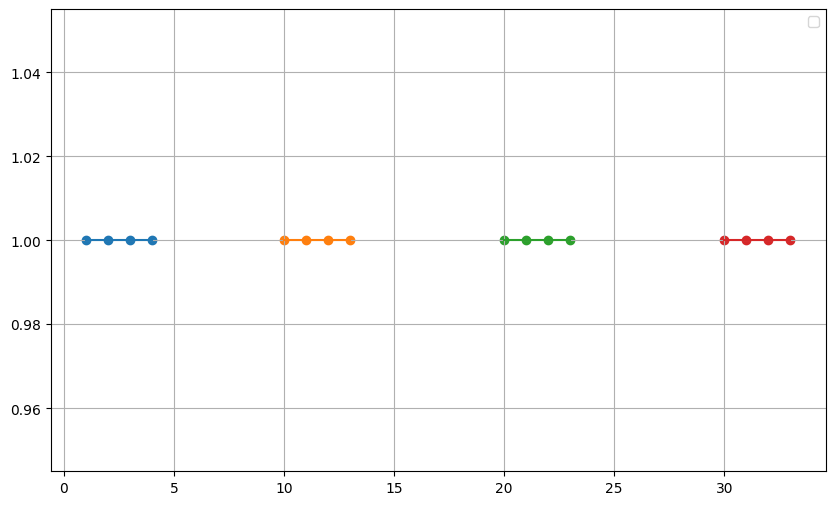

In [147]:
vc = [1,2,3,4,10,11,12,13,20,21,22,23,30,31,32,33]
ver, ver2 = middle(vc, subplot = True)

In [144]:
ver

,silhouette_avg,n_clusters,batch,cls
0,0.873236,2,2,1
1,0.673669,3,2,1
2,0.736452,3,3,1
3,0.597030,3,6,0
4,0.208927,4,2,0
5,0.735340,4,3,1
6,0.504345,4,5,0
7,0.755857,4,6,1
8,0.616004,4,8,1
9,0.546994,4,9,0


In [145]:
ver2

,silhouette_avg,n_clusters,batch,cls
0,0.873236,2,2,1


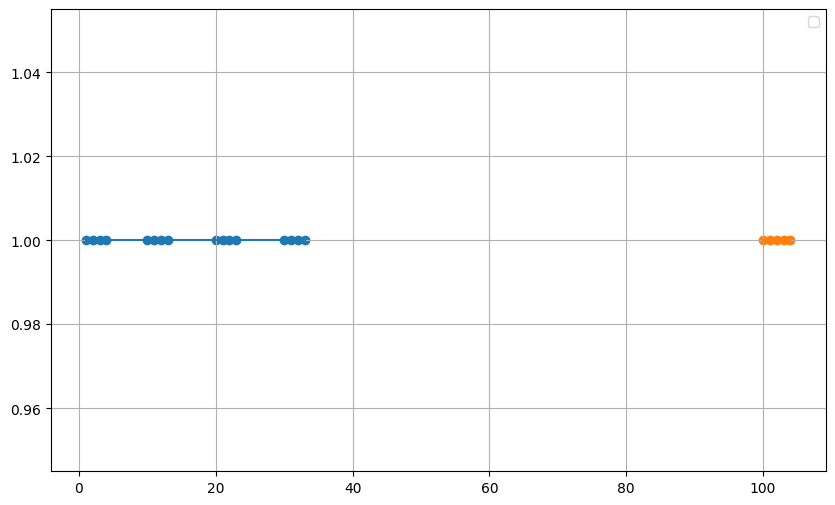

In [146]:
vc = [1,2,3,4,10,11,12,13,20,21,22,23,30,31,32,33,100,101,102,103,104]
ver, ver2 = middle(vc, subplot = True)